In [1]:
from itertools import product
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import tqdm as tqdm

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [15]:
# A linear family is defined by a basis of matrices,
# which is a 3D tensor whose first dimension indexes the basis elements.

def symmetric_toeplitz_basis(dim):
    def basis_element(i):
        ei = np.zeros(dim)
        ei[i] = 1
        return sp.linalg.toeplitz(ei)
    return np.stack([basis_element(i) for i in range(dim)])


def hankel_basis(dim):
    def first_basis_elements(i):
        ei = np.zeros(dim)
        ei[i] = 1
        return sp.linalg.hankel(ei)
    def second_basis_elements(i):
        ei = np.zeros(dim)
        ei[i] = 1
        return sp.linalg.hankel(np.zeros_like(ei), ei)
    return np.stack([first_basis_elements(i) for i in range(dim)] + [second_basis_elements(i) for i in range(1, dim)])


def antisymmetric_hankel_basis(dim):
    def basis_element(i):
        col = np.zeros(dim)
        col[i] = 1
        row = np.zeros(dim)
        row[-i-1] = 1
        return sp.linalg.hankel(col, row)
    return np.stack([basis_element(i) for i in range(dim)])


def circulant_basis(dim):
    def basis_element(i):
        ei = np.zeros(dim)
        ei[i] = 1
        return sp.linalg.circulant(ei)
    return np.stack([basis_element(i) for i in range(dim)])


def one_row_basis(dim):
    return np.eye(dim).reshape(dim, 1, dim)


def chris_scrambled_basis(dim):
    def basis_element():
        E = np.zeros((dim, dim))
        for i,j in zip(np.random.permutation(dim), range(dim)):
            E[i,j] = 1
        return E
    return np.stack([basis_element() for _ in range(dim)])

In [16]:
def best_approximation(basis, A):
    c_opt = np.linalg.lstsq(basis.reshape(len(basis), -1).T, A.flatten(), rcond=None)[0]
    return np.einsum("bij,b->ij", basis, c_opt)


def sketched_best_approximation(basis, A, S):
    c_opt = np.linalg.lstsq(np.einsum("bij,jk->bik", basis, S).reshape(len(basis), -1).T, (A @ S).flatten(), rcond=None)[0]
    return np.einsum("bij,b->ij", basis, c_opt)


def gaussian_sketched_best_approximation(basis, A, k):
    return sketched_best_approximation(basis, A, np.random.randn(A.shape[1], k))


def uniform_column_sampling_best_approximation(basis, A, k):
    n = A.shape[1]
    return sketched_best_approximation(basis, A, np.eye(n, n)[:, np.random.randint(n, size=k)])

In [17]:
# Set up experiment
def approximation_instance(basis):
    c_plant = np.random.randn(len(basis)) #+ np.arange(len(basis)) ** 2
    σ = 1  # noise level
    noise = np.random.randn(*basis.shape[1:])
    # noise = np.random.randn(*basis.shape[1:]) * np.einsum("bij,b->ij", antisymmetric_hankel_basis(len(basis)), np.arange(len(basis), 0, -1) ** 3)
    # assert noise.shape[0] == noise.shape[1]
    # noise = (noise + noise.T) / 2

    A = np.einsum("bij,b->ij", basis, c_plant) + σ * noise  # generate nearly structured matrix
    A_opt = best_approximation(basis, A)

    return A, A_opt  # TODO: should we be computing? A_opt here

In [18]:
def gaussian_trial(n, k):
    basis = hankel_basis(n)
    A, A_opt = approximation_instance(basis)
    approx = gaussian_sketched_best_approximation(basis, A, k)
    return {"Error": np.linalg.norm(A - approx), "Best Error": np.linalg.norm(A - A_opt), "Sketch": "Gaussian", "k": k, "basis_n": n}


def uniform_trial(k):
    approx = uniform_column_sampling_best_approximation(basis, A, k)
    return {"Error": np.linalg.norm(A - approx), "Sketch": "Uniform Column", "k": k}

num_trials = 5
# n=200
# ks = np.geomspace(3, n//2, 20, dtype='int')
# results = [gaussian_trial(n, k) for _ in range(num_trials) for k in ks]
# results += [uniform_trial(k) for _ in range(num_trials) for k in ks]
# results = Parallel(n_jobs=4)(delayed(gaussian_trial)(k) for _ in range(num_trials) for k in ks)

ns = [2,4,8,32,64,128,256]
k = 64
results = Parallel(n_jobs=4)(delayed(gaussian_trial)(n, k) for _ in range(num_trials) for n in ns)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


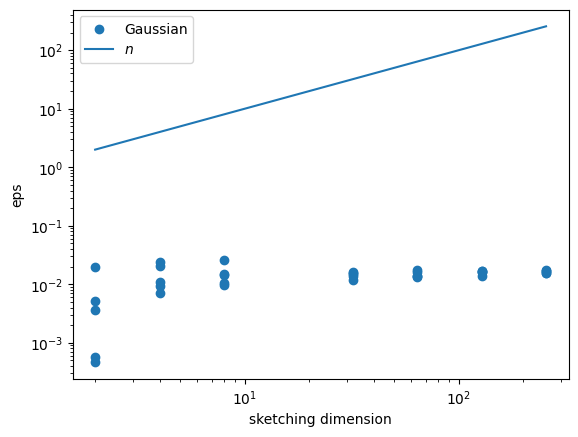

In [19]:
df = pd.DataFrame(results)
df["Relative Error"] = df["Error"] / df["Best Error"] - 1

# sns.lineplot(data=df, x="k", y="Relative Error", hue="Sketch")
# plt.plot(ks, 1/ks, label='$1/k$')
# plt.xscale('log')
# plt.yscale('log')

plt.scatter(df["basis_n"], df["Relative Error"], label="Gaussian")
# plt.plot(ks, 1/ks, label='$1/k$')
plt.plot(ns, ns, label='$n$')
plt.xlabel('sketching dimension')
plt.ylabel('eps')
plt.xscale('log')
plt.yscale('log')
plt.legend()
